In [1]:
from president.experiments.positional_dynamics.run_loader import *

## Loading the data

In [2]:
trial_id = "5_Linear"
games = load_game_log(f"run{trial_id}.csv")
players = to_player_frame(games)
games

,trial_id,game_index,num_players,president_id,vice_president_id,vice_scum_id,scum_id,winner_ids,hand_strength_prediction
0,5_Linear,0,5,<NA>,<NA>,<NA>,<NA>,"[4, 0, 3, 1, 2]","[1.1387784027790024, 0.2875792702682864, 0.464..."
1,5_Linear,1,5,4,0,1,2,"[3, 4, 0, 1, 2]","[0.4465068640565365, 1.4152083680990752, 0.877..."
2,5_Linear,2,5,3,4,1,2,"[4, 3, 0, 1, 2]","[0.976359025285177, -0.7463517568786597, -0.76..."
3,5_Linear,3,5,4,3,1,2,"[1, 4, 0, 2, 3]","[1.6530188759986055, 1.2609056408154842, -1.22..."
4,5_Linear,4,5,1,4,2,3,"[1, 3, 4, 0, 2]","[1.2680102145767622, 0.176350153001429, -0.610..."
...,...,...,...,...,...,...,...,...,...
9995,5_Linear,9995,5,2,3,0,1,"[3, 4, 2, 1, 0]","[0.8467434115227169, -0.12752750533292523, 0.6..."
9996,5_Linear,9996,5,3,4,1,0,"[4, 3, 2, 0, 1]","[1.7812263189467599, 0.8191789004191165, -1.68..."
9997,5_Linear,9997,5,4,3,0,1,"[4, 2, 3, 0, 1]","[1.1956510363316704, -1.1469933448524179, 0.96..."
9998,5_Linear,9998,5,4,2,0,1,"[4, 3, 1, 2, 0]","[1.8323415662660638, -0.3915862735792253, 1.65..."


In [3]:
players

,trial_id,game_index,num_players,player_id,seat_offset,role_this_game,finish_rank,performance,hand_strength_prediction
0,5_Linear,0,5,0,<NA>,commoner,1,1,0.287579
1,5_Linear,0,5,1,<NA>,commoner,3,-1,1.453337
2,5_Linear,0,5,2,<NA>,commoner,4,-2,-1.416247
3,5_Linear,0,5,3,<NA>,commoner,2,0,0.464426
4,5_Linear,0,5,4,<NA>,commoner,0,2,1.138778
...,...,...,...,...,...,...,...,...,...
49995,5_Linear,9999,5,0,1,scum,2,0,-0.451303
49996,5_Linear,9999,5,1,2,commoner,3,-1,0.163833
49997,5_Linear,9999,5,2,3,vice_scum,4,-2,-1.350938
49998,5_Linear,9999,5,3,4,vice_president,1,1,1.147159


# Main columns 

In [4]:
players[players.player_id == 1][
    ["seat_offset",
    "role_this_game",
     "hand_strength_prediction",
     "finish_rank"]
]

,seat_offset,role_this_game,hand_strength_prediction,finish_rank
1,<NA>,commoner,1.453337,3
6,2,vice_scum,0.454631,3
11,3,vice_scum,-0.358793,3
16,2,vice_scum,1.653019,0
21,0,president,1.268010,0
...,...,...,...,...
49976,4,scum,0.654472,3
49981,3,vice_scum,-0.036830,4
49986,2,scum,-1.108283,4
49991,2,scum,1.655652,2


## Derived columns

In [5]:
def role_value(role):
    if role == "president":
        return 2
    if role == "vice_president":
        return 1
    if role == "vice_scum":
        return -1
    if role == "scum":
        return -2
    if role == "commoner":
        return 0

In [6]:
players["current_role_value"] = players["role_this_game"].apply(role_value)

In [7]:
players[players.player_id==1][["role_this_game", "current_role_value"]]

,role_this_game,current_role_value
1,commoner,0
6,vice_scum,-1
11,vice_scum,-1
16,vice_scum,-1
21,president,2
...,...,...
49976,scum,-2
49981,vice_scum,-1
49986,scum,-2
49991,scum,-2


In [8]:
players["role_value_change"] = players.performance - players.current_role_value

## Linear models

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = players[players["game_index"]>1][["current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(role)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"current_role_value coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(role)

Intercept: 0.000
current_role_value coefficient: 0.373
R²: 0.139


In [10]:
X = players[players["game_index"]>1][["seat_offset"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset)

Intercept: 0.659
seat_offset coefficient: -0.330
R²: 0.109


In [11]:
X = players[players["game_index"]>1][["hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"hand_strength_prediction coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(hand_strength)

Intercept: -0.075
hand_strength_prediction coefficient: 0.703
R²: 0.268


In [12]:
X = players[players["game_index"]>1][["seat_offset", "current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, role)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"current_role_value coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, role)

Intercept: 0.332
seat_offset coefficient: -0.166
current_role_value coefficient: 0.274
R²: 0.157


In [13]:
X = players[players["game_index"]>1][["seat_offset", "hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, hand_strength)

Intercept: 0.394
seat_offset coefficient: -0.231
hand_strength coefficient: 0.638
R²: 0.319


In [14]:
X = players[players["game_index"]>1][["current_role_value", "hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(role, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"role coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(role, hand_strength)

Intercept: -0.064
role coefficient: 0.228
hand_strength coefficient: 0.602
R²: 0.314


In [15]:
X = players[players["game_index"]>1][["seat_offset", "hand_strength_prediction", "current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"current_role_value coefficient: {model.coef_[2]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, hand_strength)

Intercept: 0.249
seat_offset coefficient: -0.157
hand_strength coefficient: 0.598
current_role_value coefficient: 0.135
R²: 0.330


Seat offset shows a moderate correlation with a model trained on only it as input has an $r^2$ of 0.155.
Both hand_strength and current role are very correlated with performance as expected, together they dont add much more information since a high role and good hand strength are correlated. 

## Mean performance(seat_offset, role)

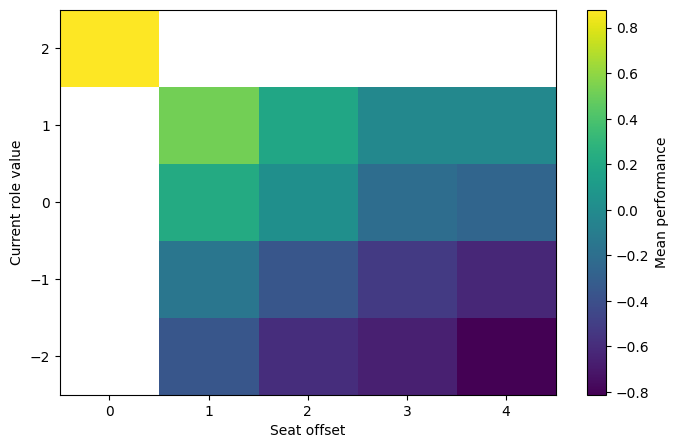

In [16]:
seat_offsets = np.unique(players[players.game_index>1]["seat_offset"])
role_values = np.unique(players[players.game_index>1]["current_role_value"] )

mean_rank = np.full(
    (len(role_values), len(seat_offsets)),
    np.nan,
)

for i, role in enumerate(role_values):
    for j, seat in enumerate(seat_offsets):
        mask = (
            (players[players.game_index>1]["seat_offset"] == seat) &
            (players[players.game_index>1]["current_role_value"] == role)
        )

        if np.any(mask):
            mean_rank[i, j] = players[players.game_index>1]["performance"][mask].mean()

plt.figure(figsize=(8, 5))

plt.imshow(
    mean_rank,
    origin="lower",
    aspect="auto",
    extent=[
        seat_offsets.min() - 0.5,
        seat_offsets.max() + 0.5,
        role_values.min() - 0.5,
        role_values.max() + 0.5,
    ],
)

plt.colorbar(label="Mean performance")
plt.xlabel("Seat offset")
plt.ylabel("Current role value")
plt.xticks(seat_offsets)
plt.yticks(role_values)

plt.show()

seat_offset=0 means president, which means its only current role value is 2, which has high average performance.
A slight tendency can be seen of seat_offset=1 having greater mean performance than other offsets

## Hand strength predictor statistics

In [17]:
def hand_strength_stats(performance):
    mean = players[(players.game_index>1) & (players.performance==performance)]["hand_strength_prediction"].mean()
    std = players[(players.game_index>1) & (players.performance==performance)]["hand_strength_prediction"].std()
    print(f"Performance:{performance}\tPrediction: mean: {mean:.2f}\tstd:{std:.2f}")

for performance in players.performance.unique():
    hand_strength_stats(performance)


Performance:1	Prediction: mean: 0.41	std:0.90
Performance:-1	Prediction: mean: -0.29	std:0.92
Performance:-2	Prediction: mean: -0.58	std:0.87
Performance:0	Prediction: mean: 0.01	std:0.94
Performance:2	Prediction: mean: 0.98	std:0.79


The hand strength predictor successfully trained and its outputs generally correlate with game outcome

## Change in presidents

/tmp/ipykernel_1121262/1697880563.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_presidents = players[players.game_index>1][


Text(0, 0.5, 'Count')

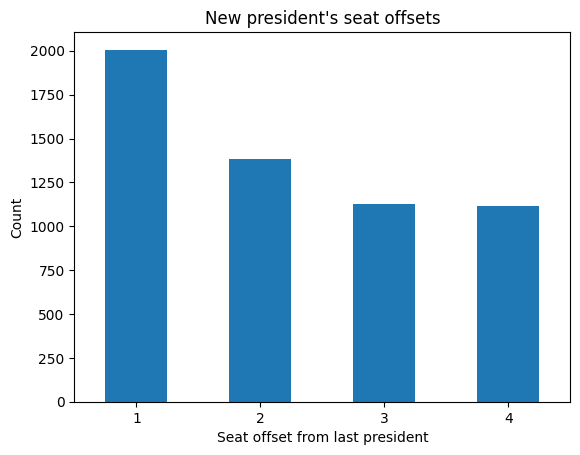

In [18]:
new_presidents = players[players.game_index>1][
    (players.performance==2) &
    (players.current_role_value<2)
]
counts = new_presidents.seat_offset.value_counts(sort=False).sort_index()

ax = counts.plot(kind="bar")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")

Players seated one seat after the president seem more likely to become the new president, but this tendency is modest, to make this tendency rigurous we make a statistical analysis

/tmp/ipykernel_1121262/1004368798.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_presidents = players[players.game_index > 1][


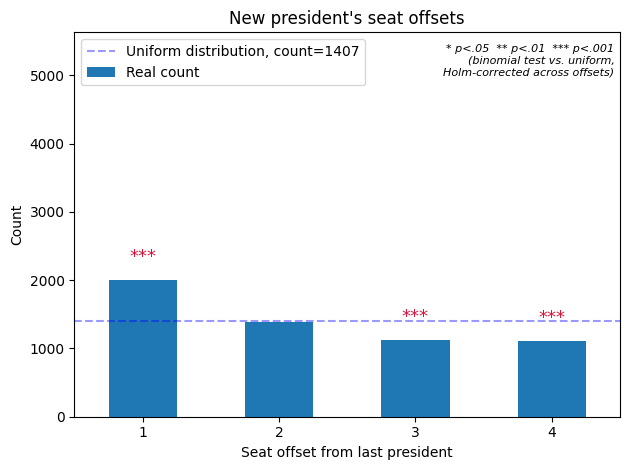

In [19]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

new_presidents = players[players.game_index > 1][
    (players.performance == 2) & (players.current_role_value < 2)
]

counts = new_presidents.seat_offset.value_counts(sort=False).sort_index()

n = counts.sum()
k = len(counts)
p_null = 1 / k  # equal probability per offset under H0

# per-offset exact binomial test vs the uniform null
pvals = [stats.binomtest(c, n, p_null, alternative="two-sided").pvalue for c in counts]

# multiple-comparison correction across the k offsets tested
reject, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

ax = counts.plot(kind="bar", label="Real count")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.sum())
ax.axhline(
    y=counts.sum()/counts.shape[0],
    color='b',
    linestyle='--',
    alpha = 0.4,
    label=f"Uniform distribution, count={counts.sum()/counts.shape[0]:.0f}"
)

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

ymax = counts.max()
for i, p_adj in enumerate(pvals_adj):
    s = stars(p_adj)
    if s:
        ax.text(i, counts.iloc[i] + ymax * 0.1, s,
                ha="center", va="bottom", fontsize=13, color="crimson")

ax.text(
    0.99, 0.97,
    "* p<.05  ** p<.01  *** p<.001\n(binomial test vs. uniform,\nHolm-corrected across offsets)",
    transform=ax.transAxes, ha="right", va="top", fontsize=8, style="italic",
)

ax.legend()
plt.tight_layout()
plt.show()


We can see seat_offset = 1 advantage is statistically significant, we also see some of the rest of the seats disadvantaged as would be expected to compensate.

Interestingly, the last seat doesnt seem to be disadvantaged with respect to the uniform, according to our hypothesis, the last seat is disadvantaged due to playing its biggest cards right before president, meaning his high cards are likely to be lost.

One possible explanation to this is a back-and-forth tendency, where when presidents lose, they are likely to go down to vice-president, and its likely that they lost to the player at seat_offset=1, meaning now they are the player at seat_offset=n-1 which disadvantages them, but not enough to outweigh their role as vice-president 

In [20]:
losing_presidents = players[
    (players.game_index > 1) &
    (players.current_role_value == 2) &
    (players.performance < 2)
]

losing_presidents.performance.value_counts()

performance
1     2402
0     1530
-1    1038
-2     658
Name: count, dtype: Int64

Indeed, presidents overwhelmingly become vice-presidents after losing

role_this_game  scum  vice_scum  commoner  vice_president
seat_offset                                              
1                139        245       412            1210
2                165        250       515             451
3                203        255       315             353
4                163        213       348             391


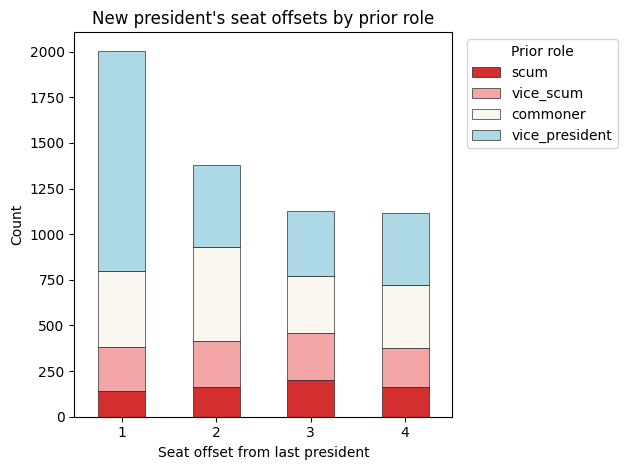

In [21]:
role_order = ["scum", "vice_scum", "commoner", "vice_president"]  # bottom -> top of stack
role_colors = {
    "scum":       "#D32F2F",  # red
    "vice_scum":  "#F4A6A6",  # light red
    "commoner":   "#FAF6F0",  # off-white
    "vice_president":       "#ADD8E6",  # light blue
}

new_presidents = players[
    (players.game_index > 1) &
    (players.performance == 2) &
    (players.current_role_value < 2)
]

pivot = (
    new_presidents
    .groupby(["seat_offset", "role_this_game"])
    .size()
    .unstack("role_this_game")
    .reindex(columns=role_order)  # forces column order = stack order
    .sort_index()
)
print(pivot)

totals = pivot.sum(axis=1)

ax = pivot.plot(
    kind="bar", stacked=True,
    color=[role_colors[r] for r in role_order],
    edgecolor="black", linewidth=0.4,
)
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets by prior role")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")
ax.legend(title="Prior role", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Its not clear whether the lack of disadvantage in the last seat is due to overrepresentation of vice-presidents retaking the rule or its due to something else 